In [1]:
!pip install -q vaderSentiment scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import re

In [3]:
gold = pd.read_csv('tweets_gold_standard.csv')
xlm_full = pd.read_csv('xlm-roberta_results.csv')
mbert_full = pd.read_csv('mbert_results.csv')

gold['tweet_id'] = gold['tweet_id'].astype(str).str.strip()
xlm_full['tweet_id'] = xlm_full['tweet_id'].astype(str).str.strip()
mbert_full['tweet_id'] = mbert_full['tweet_id'].astype(str).str.strip()

print(f'Gold: {len(gold)}, XLM: {len(xlm_full)}, mBERT: {len(mbert_full)}')

Gold: 498, XLM: 27318, mBERT: 27318


In [4]:
print(list(xlm_full.columns))
print(list(mbert_full.columns))

['tweet_id', 'username', 'raw_content', 'athlete_name', 'athlete_display_name', 'translated_content', 'xlm-roberta_sentiment', 'xlm-roberta_score', 'xlm-roberta_original']
['tweet_id', 'username', 'raw_content', 'athlete_name', 'athlete_display_name', 'translated_content', 'mbert_sentiment', 'mbert_score', 'mbert_original']


In [5]:
LABELS = ['positive', 'neutral', 'negative']

def normalize_label(val):
    v = str(val).strip().lower()
    mapping = {
        'positive': 'positive', 'pos': 'positive',
        'negative': 'negative', 'neg': 'negative',
        'neutral': 'neutral', 'neu': 'neutral'
    }
    return mapping.get(v, v)

gold_ids = set(gold['tweet_id'].values)
xlm_498 = xlm_full[xlm_full['tweet_id'].isin(gold_ids)].copy()
mbert_498 = mbert_full[mbert_full['tweet_id'].isin(gold_ids)].copy()

df = gold[['tweet_id', 'raw_content', 'gold_sentiment', 'athlete_display_name']].copy()
df['gold'] = df['gold_sentiment'].apply(normalize_label)

xlm_m = xlm_498[['tweet_id', 'translated_content',
                  'xlm-roberta_sentiment',
                  'xlm-roberta_score']].copy()
xlm_m.columns = ['tweet_id', 'translated_text', 'xlm_pred', 'xlm_conf']
xlm_m['xlm_pred'] = xlm_m['xlm_pred'].apply(normalize_label)

mbert_m = mbert_498[['tweet_id',
                      'mbert_sentiment',
                      'mbert_score']].copy()
mbert_m.columns = ['tweet_id', 'mbert_pred', 'mbert_conf']
mbert_m['mbert_pred'] = mbert_m['mbert_pred'].apply(normalize_label)

df = df.merge(xlm_m, on='tweet_id', how='inner')
df = df.merge(mbert_m, on='tweet_id', how='inner')

analyzer = SentimentIntensityAnalyzer()
def vader_label(text):
    s = analyzer.polarity_scores(str(text))['compound']
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df['vader_trans'] = df['translated_text'].apply(vader_label)

df['xlm_correct'] = df['xlm_pred'] == df['gold']
df['mbert_correct'] = df['mbert_pred'] == df['gold']
df['vader_correct'] = df['vader_trans'] == df['gold']
df['all_wrong'] = ~df['xlm_correct'] & ~df['mbert_correct'] & ~df['vader_correct']
df['any_model_wrong'] = ~df['xlm_correct'] | ~df['mbert_correct']

print(f'Merged: {len(df)}')
print(f'XLM wrong: {(~df["xlm_correct"]).sum()}')
print(f'mBERT wrong: {(~df["mbert_correct"]).sum()}')
print(f'VADER wrong: {(~df["vader_correct"]).sum()}')
print(f'All 3 wrong: {df["all_wrong"].sum()}')
print(f'Any wrong: {df["any_model_wrong"].sum()}')

Merged: 498
XLM wrong: 224
mBERT wrong: 187
VADER wrong: 216
All 3 wrong: 69
Any wrong: 304


In [6]:
def has_hindi(text):
    return bool(re.search(r'[\u0900-\u097F]', str(text)))

def has_emoji(text):
    return bool(re.search(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U0001f900-\U0001f9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF]', str(text)))

def has_sarcasm_markers(text):
    t = str(text).lower()
    return any(m in t for m in ['lol', 'lmao', 'rofl', 'haha', '/s', 'yeah right', 'sure', 'wow', 'bravo', 'wah', 'waah', 'kya baat'])

def has_romanized_hindi(text):
    t = str(text).lower()
    hindi_words = ['hai', 'nahi', 'kya', 'yeh', 'woh', 'acha', 'bhai', 'yaar',
                   'bahut', 'bohot', 'tera', 'mera', 'sala', 'chutiya', 'gadha',
                   'karo', 'karna', 'dekho', 'suno', 'jao', 'aao', 'desh',
                   'bharat', 'jeet', 'haar', 'khel', 'sahi']
    words = set(re.findall(r'\b\w+\b', t))
    return len(words.intersection(hindi_words)) >= 2

def categorize_error(row):
    text = str(row['raw_content'])
    cats = []
    if has_hindi(text) or has_romanized_hindi(text):
        cats.append('code_mixed')
    if has_sarcasm_markers(text):
        cats.append('sarcasm_irony')
    if row['gold'] == 'neutral' and row['xlm_pred'] != 'neutral' and row['mbert_pred'] != 'neutral':
        cats.append('neutral_misclassified')
    if has_emoji(text):
        cats.append('emoji_dependent')
    if len(text.split()) < 5:
        cats.append('very_short')
    if len(text.split()) > 30:
        cats.append('long_complex')
    if not cats:
        cats.append('other')
    return '|'.join(cats)

errors = df[df['any_model_wrong']].copy()
errors['error_cats'] = errors.apply(categorize_error, axis=1)
print(f'Tweets with at least one model error: {len(errors)} ({100*len(errors)/len(df):.1f}%)')

Tweets with at least one model error: 304 (61.0%)


In [7]:
all_cats = []
for cats in errors['error_cats']:
    all_cats.extend(cats.split('|'))

cat_counts = pd.Series(all_cats).value_counts()
print('=== ERROR CATEGORY DISTRIBUTION ===')
for cat, count in cat_counts.items():
    print(f'  {cat:25s} {count:4d} ({100*count/len(errors):.1f}% of errors)')

=== ERROR CATEGORY DISTRIBUTION ===
  other                      198 (65.1% of errors)
  code_mixed                  42 (13.8% of errors)
  emoji_dependent             37 (12.2% of errors)
  long_complex                33 (10.9% of errors)
  sarcasm_irony               12 (3.9% of errors)
  neutral_misclassified       10 (3.3% of errors)
  very_short                   9 (3.0% of errors)


In [8]:
print('=== TOP CONFUSION PATTERNS (Gold -> XLM, mBERT) ===')
patterns = errors.groupby(['gold', 'xlm_pred', 'mbert_pred']).size().reset_index(name='count')
patterns = patterns.sort_values('count', ascending=False)
print(patterns.head(15).to_string(index=False))

=== TOP CONFUSION PATTERNS (Gold -> XLM, mBERT) ===
    gold xlm_pred mbert_pred  count
negative  neutral   negative     69
positive  neutral   negative     47
positive  neutral   positive     35
 neutral  neutral   positive     24
 neutral  neutral   negative     23
positive negative   negative     23
positive positive   negative     19
negative  neutral   positive     12
negative positive   negative      8
negative negative   positive      7
 neutral positive   positive      6
positive  neutral    neutral      6
negative positive   positive      5
negative negative    neutral      4
positive negative   positive      4


In [9]:
print('=== ERROR RATE BY ATHLETE ===')
athlete_err = df.groupby('athlete_display_name').agg(
    total=('xlm_correct', 'count'),
    xlm_err=('xlm_correct', lambda x: (~x).sum()),
    mbert_err=('mbert_correct', lambda x: (~x).sum()),
    vader_err=('vader_correct', lambda x: (~x).sum())
)
athlete_err['xlm_%'] = (athlete_err['xlm_err'] / athlete_err['total'] * 100).round(1)
athlete_err['mbert_%'] = (athlete_err['mbert_err'] / athlete_err['total'] * 100).round(1)
athlete_err['vader_%'] = (athlete_err['vader_err'] / athlete_err['total'] * 100).round(1)
print(athlete_err.to_string())

=== ERROR RATE BY ATHLETE ===
                      total  xlm_err  mbert_err  vader_err  xlm_%  mbert_%  vader_%
athlete_display_name                                                               
Harmanpreet Kaur         83       39         38         42   47.0     45.8     50.6
Sakshi Malik             83       32         30         42   38.6     36.1     50.6
Sarita Devi              83       38         39         40   45.8     47.0     48.2
Sushil Kumar             83       25         15         16   30.1     18.1     19.3
Vijender Singh           83       53         21         42   63.9     25.3     50.6
Virat Kohli              83       37         44         34   44.6     53.0     41.0


In [10]:
print('=== 50 SAMPLE ERRORS ===')
sample = errors[['raw_content', 'gold', 'xlm_pred', 'mbert_pred', 'vader_trans', 'error_cats']].sample(
    n=min(50, len(errors)), random_state=42
)
sample.to_csv('error_samples_50.csv', index=False)
print('Saved to error_samples_50.csv')
for _, row in sample.head(10).iterrows():
    txt = str(row['raw_content'])[:120]
    print(f'\n[{row["error_cats"]}]')
    print(f'  "{txt}{"..." if len(str(row["raw_content"])) > 120 else ""}"')
    print(f'  Gold={row["gold"]} | XLM={row["xlm_pred"]} | mBERT={row["mbert_pred"]} | VADER={row["vader_trans"]}')

=== 50 SAMPLE ERRORS ===
Saved to error_samples_50.csv

[other]
  "Ise kehte hai nada dhila ho jana"@PTI_News: Sports Ministry asks NADA to carry out test on boxer Vijender Singh.""
  Gold=negative | XLM=neutral | mBERT=negative | VADER=neutral

[other]
  "WATCH: Harmanpreet Kaur ramps up seven outrageous sixes enroute to her unbeaten 171 vs Australia https://t.co/qBuo0NhaQZ"
  Gold=positive | XLM=negative | mBERT=negative | VADER=negative

[emoji_dependent]
  "Video shoot of Pappu 😂🤭 https://t.co/jjDz9AzrXw"
  Gold=neutral | XLM=neutral | mBERT=positive | VADER=positive

[other]
  "Suspension of Sarita Devi has created grave concern among people of my country &amp; sportspersons: Sports Min Sarbanand..."
  Gold=positive | XLM=negative | mBERT=negative | VADER=negative

[emoji_dependent|long_complex]
  "#WrestlerProtest | The Rouse Avenue Court in Delhi to hear the case on the charge sheet filed in the #BrijBhushanSharanS..."
  Gold=negative | XLM=neutral | mBERT=negative | VADER=negat

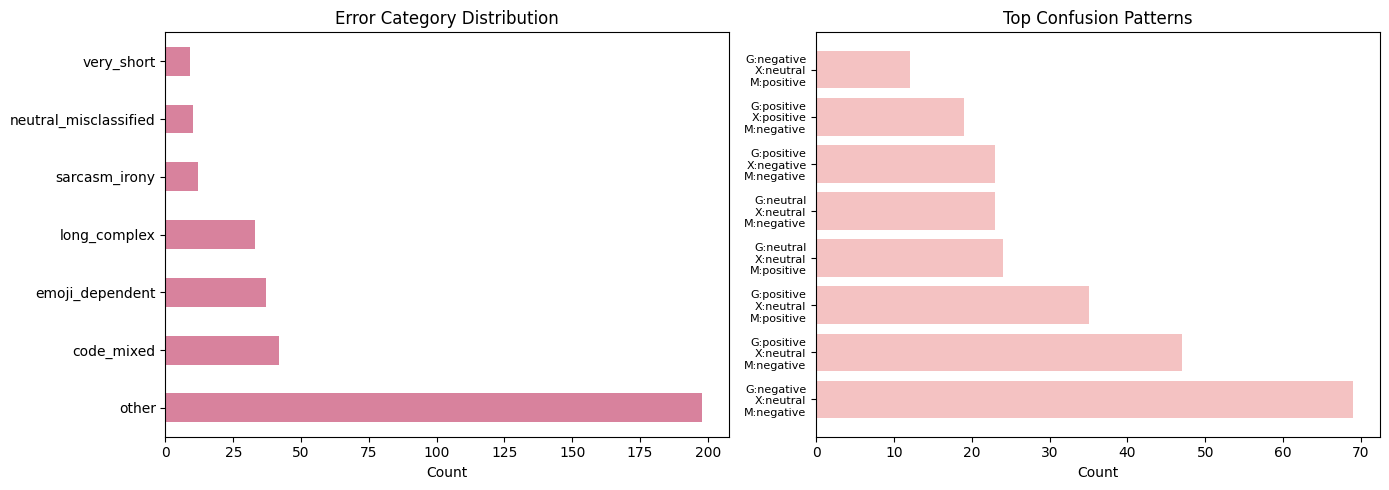

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts.plot(kind='barh', ax=axes[0], color='#D8829D')
axes[0].set_title('Error Category Distribution')
axes[0].set_xlabel('Count')

top = patterns.head(8)
labels = [f'G:{r["gold"]}\nX:{r["xlm_pred"]}\nM:{r["mbert_pred"]}' for _, r in top.iterrows()]
axes[1].barh(range(len(top)), top['count'], color='#F4C2C2')
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_title('Top Confusion Patterns')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('fig_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print('=== PAPER-READY SUMMARY ===')
print(f'Evaluated: {len(df)} tweets')
print(f'At least one model wrong: {len(errors)} ({100*len(errors)/len(df):.1f}%)')
print(f'All models correct: {len(df)-len(errors)} ({100*(len(df)-len(errors))/len(df):.1f}%)')
print(f'All 3 wrong: {df["all_wrong"].sum()} ({100*df["all_wrong"].sum()/len(df):.1f}%)')
print(f'\nTop error categories:')
for cat, count in cat_counts.head(5).items():
    print(f'  {cat}: {count} ({100*count/len(errors):.1f}%)')
if len(patterns) > 0:
    t = patterns.iloc[0]
    print(f'\nMost common pattern:')
    print(f'  Gold={t["gold"]}, XLM={t["xlm_pred"]}, mBERT={t["mbert_pred"]}: {t["count"]} tweets')

=== PAPER-READY SUMMARY ===
Evaluated: 498 tweets
At least one model wrong: 304 (61.0%)
All models correct: 194 (39.0%)
All 3 wrong: 69 (13.9%)

Top error categories:
  other: 198 (65.1%)
  code_mixed: 42 (13.8%)
  emoji_dependent: 37 (12.2%)
  long_complex: 33 (10.9%)
  sarcasm_irony: 12 (3.9%)

Most common pattern:
  Gold=negative, XLM=neutral, mBERT=negative: 69 tweets
